In [ ]:
from qiskit import QuantumCircuit

def get_circuit(angle_left, angle_right):
    circ = QuantumCircuit(2)
    circ.h(0) # ایجاد برهم‌نهی روی کیوبیت ۰
    circ.cx(0, 1)       # درهم‌تنیدگی (Bell state)
    circ.x(1)
    circ.barrier()
    circ.ry(angle_left, 0)             # چرخش کیوبیت ۰ به اندازه angle_left
    circ.ry(angle_right, 1)             # چرخش کیوبیت ۱ به اندازه angle_right
    circ.measure_all()
    display(circ.draw('mpl'))
    return circ   

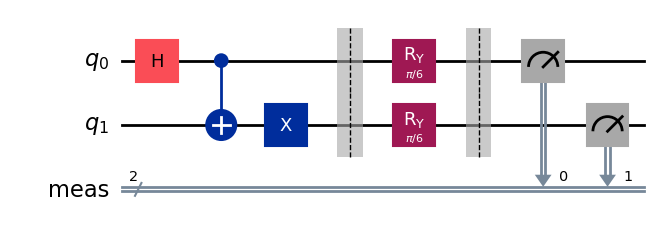

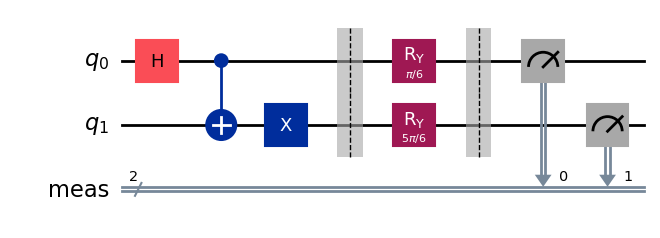

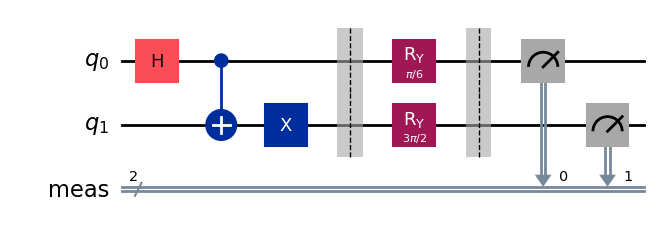

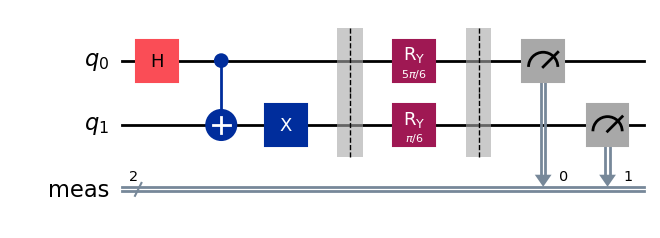

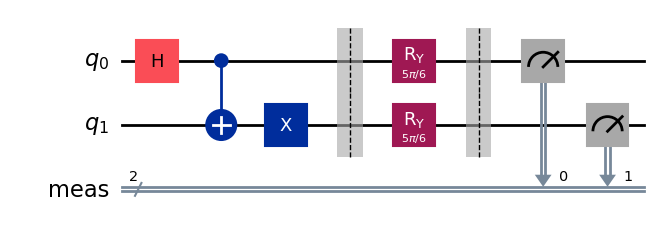

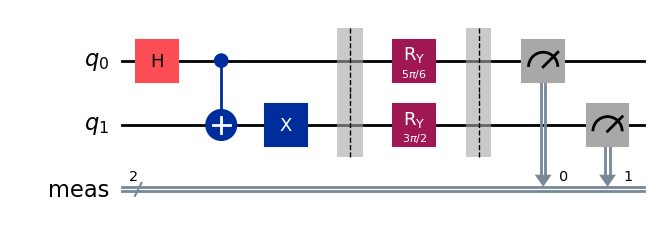

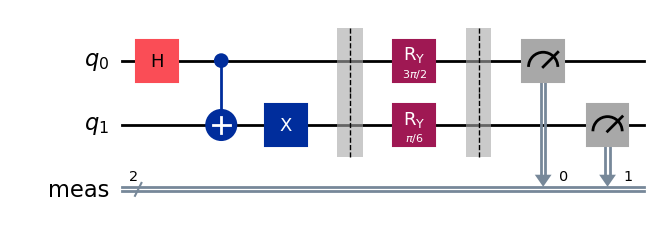

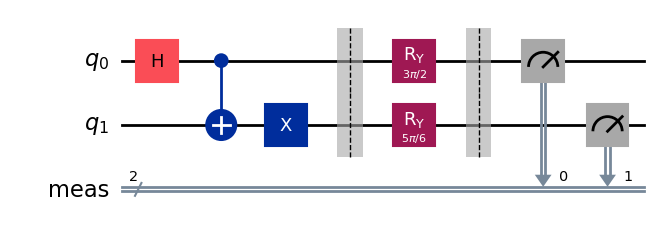

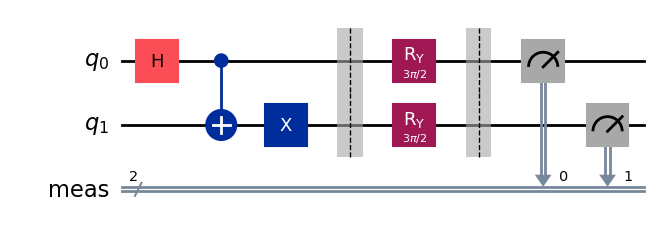

In [ ]:
from math import pi
northwest = pi/6
southwest = 5*pi/6
east = 9*pi/6
directions = [northwest, southwest, east]          # لیست جهات
circuits = []
for dir_left in directions:                       # ساخت همه ترکیب‌های ممکن زوج زاویه
    for dir_right in directions:
        circuits.append(
            get_circuit(dir_left, dir_right)
        )


In [ ]:
from qiskit_aer import AerSimulator
from qiskit import transpile
#شیء شبیه‌ساز AerSimulator را ایجاد می‌کنیم و تعداد شات‌ها را مشخص می‌کنیم

backend = AerSimulator()
shots=100

transpiled_circuits = transpile(circuits, backend)

job = backend.run(circuits, backend=backend, shots=shots, memory=True)
result = job.result()


In [ ]:
# محاسبه احتمال عدم توافق
disagree = 0
for circ in circuits:
    memory = result.get_memory(circ)
    for meas in memory:
        if meas[0] != meas[1]:
            disagree += 1

print('\nProbability of disagreement: ', end="")
print(disagree/(9*shots))


Probability of disagreement: 0.4888888888888889


In [12]:
print(memory)

['00', '11', '00', '11', '00', '11', '11', '11', '00', '11', '00', '00', '11', '11', '11', '11', '00', '00', '11', '11', '00', '11', '00', '00', '00', '00', '11', '00', '11', '00', '11', '11', '11', '11', '11', '00', '11', '00', '11', '11', '11', '00', '00', '00', '00', '11', '00', '11', '11', '00', '00', '11', '00', '00', '00', '00', '11', '00', '11', '11', '00', '11', '00', '11', '11', '11', '00', '00', '00', '11', '11', '00', '11', '00', '11', '11', '11', '11', '00', '00', '00', '00', '11', '00', '11', '00', '00', '00', '11', '00', '00', '00', '11', '11', '11', '00', '11', '00', '00', '11']
